# Machine Learning Models Benchmark for P300 Classification

This notebook provides a comprehensive benchmark of multiple ML models for P300 EEG classification.

## Objectives:
1. Compare traditional ML models (SVM, Random Forest, Decision Tree, XGBoost, KNN, Logistic Regression, LDA)
2. Evaluate different data augmentation strategies (Baseline, Copy-Paste, SMOTE, GAN)
3. Test on real EEG data (Subject 3, Session 3)

## Metrics:
- Accuracy
- Balanced Accuracy
- AUC-ROC


## 0. Path Setup

Add project source folder to Python path to enable imports.

In [1]:
# =============================================================================
# PATH SETUP - Add src folder to Python path
# =============================================================================

import sys
from pathlib import Path

# Add project root and src folder to Python path
project_root = Path.cwd().parent
src_path = project_root / 'src' / 'eeg_synthetic'

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'✓ Added to Python path:')
print(f'  {src_path}')
print(f'  {project_root}')

✓ Added to Python path:
  /home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main/src/eeg_synthetic
  /home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main


## 1. Setup and Imports

Import all required libraries for data processing, modeling, and evaluation.

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# PyTorch
import torch
from torch.utils.data import TensorDataset

# Signal processing
from scipy import signal, linalg

# Scikit-learn classifiers
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pyriemann.estimation import XdawnCovariances
from pyriemann.classification import MDM
# XGBoost
from xgboost import XGBClassifier

# Metrics and preprocessing
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    roc_auc_score, 
    roc_curve,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Data augmentation
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Custom modules
from data_loader import BCIAUTLoader, plot_normalized_arrays

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 2. Load Real EEG Data

Load training and test data for Subject 3, Session 3.

Dataset path: /home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main/notebooks/data
Loading - Subjects: [3], Sessions: [3], Modes: ['Train']


/home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main/src/eeg_synthetic/data_loader.py:179: RuntimeWarning: filter_length (8251) is longer than the signal (350), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=15.0, fir_design='firwin', verbose=False)


-> Total loaded: (1600, 8, 128) - Classes: (array([0, 1]), array([1400,  200]))
Loading - Subjects: [3], Sessions: [3], Modes: ['Test']


/home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main/src/eeg_synthetic/data_loader.py:179: RuntimeWarning: filter_length (8251) is longer than the signal (350), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=15.0, fir_design='firwin', verbose=False)


-> Total loaded: (2800, 8, 128) - Classes: (array([0, 1]), array([2450,  350]))

✓ Data loaded:
  Train: (1600, 8, 128) - Class 0: 1400, Class 1: 200
  Test:  (2800, 8, 128) - Class 0: 2450, Class 1: 350
--- Generating ERP Plots ---


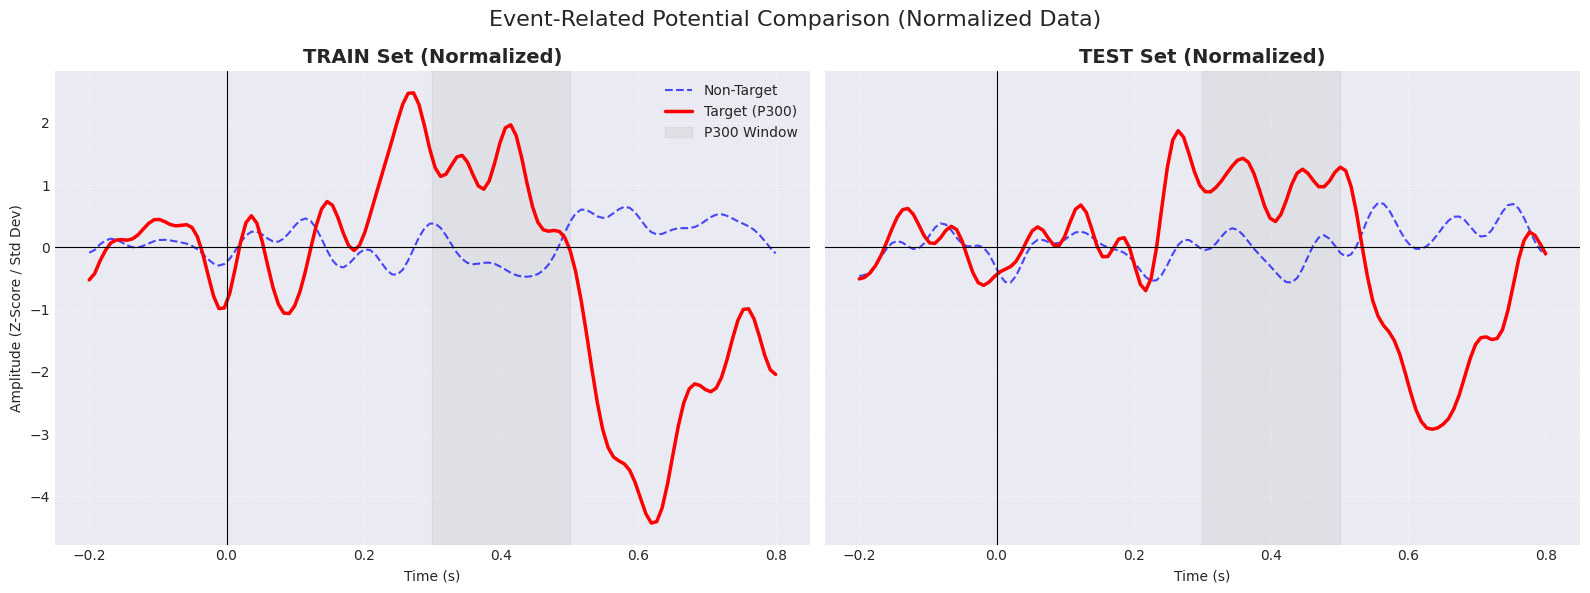

In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================

# Configure paths
project_root = os.getcwd()
dataset_path = os.path.join(project_root, 'data')
print(f'Dataset path: {dataset_path}')

# Initialize data loader
loader = BCIAUTLoader(dataset_path)

# Load training data (Subject 3, Session 3)
# Returns: (trials, channels, timepoints)
X_train_sess, y_train_sess, subjects_train_ids, session_train_ids = loader.get_data(
    subjects=[3], 
    sessions=[3], 
    modes=['Train']
)

# Load test data (Subject 3, Session 3)
X_test_sess, y_test_sess, subjects_test_ids, session_test_ids = loader.get_data(
    subjects=[3], 
    sessions=[3], 
    modes=['Test']
)

print(f'\n✓ Data loaded:')
print(f'  Train: {X_train_sess.shape} - Class 0: {(y_train_sess==0).sum()}, Class 1: {(y_train_sess==1).sum()}')
print(f'  Test:  {X_test_sess.shape} - Class 0: {(y_test_sess==0).sum()}, Class 1: {(y_test_sess==1).sum()}')

# Visualize data distribution
plot_normalized_arrays(X_train_sess, y_train_sess, X_test_sess, y_test_sess)

## 3. Load Synthetic GAN Data

Load synthetic EEG data generated by GAN (both classes).

In [4]:
# =============================================================================
# LOAD SYNTHETIC DATA
# =============================================================================

def load_balanced_synthetic_limited(path_c0, path_c1, max_trials=1200):
    """
    Load synthetic EEG data from CSV files (both classes).
    
    Parameters:
    -----------
    path_c0 : str
        Path to Class 0 (Nontarget) CSV file
    path_c1 : str
        Path to Class 1 (P300) CSV file
    max_trials : int
        Maximum number of trials to load per class
    
    Returns:
    --------
    X0_trial, y0_trial, X1_trial, y1_trial : torch.Tensor
        Synthetic data for both classes
    """
    rows_to_read = max_trials * 8  # 8 channels per trial

    def get_data_from_csv(path):
        if not os.path.exists(path):
            print(f"ERROR: File not found {path}")
            return None, None
        
        df = pd.read_csv(path, nrows=rows_to_read)
        time_cols = [col for col in df.columns if col.startswith('Time')]
        X = df[time_cols].values
        y = df['Condition'].values
        return X, y
    
    # Load Class 0 (Nontarget)
    print(f"Loading first {max_trials} trials for Class 0...")
    X0_rows, y0_rows = get_data_from_csv(path_c0)
    X0_trial = torch.tensor(X0_rows).view(-1, 8, 128)
    y0_trial = torch.tensor(y0_rows[::8])  # Take every 8th label (one per trial)
    
    # Load Class 1 (P300)
    print(f"Loading first {max_trials} trials for Class 1...")
    X1_rows, y1_rows = get_data_from_csv(path_c1)
    X1_trial = torch.tensor(X1_rows).view(-1, 8, 128)
    y1_trial = torch.tensor(y1_rows[::8])

    return X0_trial, y0_trial, X1_trial, y1_trial

# Load synthetic data
file_c0 = 'generated_samples/gen_data_c0_s3_sess3.csv'
file_c1 = 'generated_samples/gen_data_c1_s3_sess3.csv'

X0_syn, y0_syn, X1_syn, y1_syn = load_balanced_synthetic_limited(
    file_c0, 
    file_c1, 
    max_trials=8600
)

# Combine both classes
X_syn_final = torch.cat([X0_syn, X1_syn], dim=0)
y_syn_final = torch.cat([y0_syn, y1_syn], dim=0)

print(f'\n✓ Synthetic data loaded:')
print(f'  Shape: X={X_syn_final.shape}, y={y_syn_final.shape}')
print(f'  Class 0: {(y_syn_final==0).sum()}, Class 1: {(y_syn_final==1).sum()}')

Loading first 8600 trials for Class 0...
Loading first 8600 trials for Class 1...

✓ Synthetic data loaded:
  Shape: X=torch.Size([3800, 8, 128]), y=torch.Size([3800])
  Class 0: 1200, Class 1: 2600


## 4. Signal Processing Functions

Define preprocessing functions for filtering and baseline correction.

In [5]:
# =============================================================================
# SIGNAL PROCESSING FUNCTIONS
# =============================================================================

def mne_style_iir_filter(data, fs=128):
    """
    Apply bandpass IIR filter (0.1-15 Hz) to EEG data.
    
    Parameters:
    -----------
    data : np.ndarray
        EEG data (trials, channels, timepoints)
    fs : int
        Sampling frequency in Hz
    
    Returns:
    --------
    filtered_data : np.ndarray
        Filtered EEG data
    """
    low_cutoff = 0.1   # High-pass cutoff (Hz)
    high_cutoff = 15.0  # Low-pass cutoff (Hz)
    order = 4           # Filter order
    
    # Design Butterworth bandpass filter
    b, a = signal.butter(order, [low_cutoff, high_cutoff], btype='bandpass', fs=fs)
    
    # Apply zero-phase filtering
    return signal.filtfilt(b, a, data, axis=-1)


def apply_final_alignment(x_tensor):
    """
    Apply filtering and baseline correction to EEG data.
    
    Steps:
    1. Apply bandpass filter (0.1-15 Hz)
    2. Baseline correction using pre-stimulus period (indices 0-26 = -0.2s to 0s)
    
    Parameters:
    -----------
    x_tensor : torch.Tensor
        Input EEG data (trials, channels, timepoints)
    
    Returns:
    --------
    aligned_tensor : torch.Tensor
        Processed EEG data
    """
    # Convert to numpy for signal processing
    x_np = x_tensor.detach().cpu().numpy()
    
    # Apply IIR bandpass filter (0.1-15 Hz)
    x_filtered = mne_style_iir_filter(x_np, fs=128)
    
    # Baseline correction: subtract mean of pre-stimulus period
    # Indices 0-26 correspond to -0.2s to 0s (at 128 Hz sampling rate)
    baseline_period = x_filtered[:, :, :26]
    baseline_mean = np.mean(baseline_period, axis=-1, keepdims=True)
    x_aligned = x_filtered - baseline_mean
    
    # Convert back to tensor
    return torch.from_numpy(x_aligned.copy()).float()


def apply_trial_wise_std(tensor):
    """
    Apply trial-wise z-score normalization.
    
    Parameters:
    -----------
    tensor : torch.Tensor
        Input data (trials, channels, timepoints)
    
    Returns:
    --------
    normalized_tensor : torch.Tensor
        Normalized data
    """
    mu = tensor.mean(dim=(1, 2), keepdim=True)
    std = tensor.std(dim=(1, 2), keepdim=True)
    return (tensor - mu) / (std + 1e-8)


print('✓ Signal processing functions defined')

✓ Signal processing functions defined


## 5. Data Preprocessing Pipeline

Apply filtering, baseline correction, and normalization to all data.

In [6]:
# =============================================================================
# DATA PREPROCESSING PIPELINE
# =============================================================================

print('\nApplying preprocessing pipeline...')

# Step 1: Apply filtering and baseline correction
X_syn_ready_raw = apply_final_alignment(X_syn_final)
X_train_ready_raw = apply_final_alignment(torch.tensor(X_train_sess).float())
X_test_ready_raw = apply_final_alignment(torch.tensor(X_test_sess).float())

# Step 2: Apply trial-wise standardization
X_train_real_ready = apply_trial_wise_std(X_train_ready_raw).permute(0, 2, 1)  # (trials, time, channels)
X_test_real_ready = apply_trial_wise_std(X_test_ready_raw).permute(0, 2, 1)
X_syn_ready_perm = apply_trial_wise_std(X_syn_ready_raw).permute(0, 2, 1)

# Get dimensions
n_trials_tr, n_times, n_channels = X_train_real_ready.shape

# Step 3: Flatten for traditional ML models
X_train_real_flat = X_train_real_ready.reshape(n_trials_tr, -1).cpu().numpy()
y_train_real_np = np.array(y_train_sess)

X_test_real_flat = X_test_real_ready.reshape(X_test_real_ready.shape[0], -1).cpu().numpy()
y_test_real_np = np.array(y_test_sess)
X_test_3d = X_test_real_flat.reshape(-1, n_times, n_channels)  # Keep 3D for xDAWN

# Prepare synthetic data
X_gan_all_flat = X_syn_ready_perm.reshape(X_syn_ready_perm.shape[0], -1).cpu().numpy()
y_gan_all_np = y_syn_final.cpu().numpy()

# Extract only Class 1 (P300) from synthetic data for augmentation
X_gan_c1_flat = X_gan_all_flat[y_gan_all_np == 1.0]
y_gan_c1_np = y_gan_all_np[y_gan_all_np == 1.0]

print(f'\n✓ Preprocessing complete:')
print(f'  Real train (flat): {X_train_real_flat.shape}')
print(f'  Real test (flat): {X_test_real_flat.shape}')
print(f'  Synthetic C1 (flat): {X_gan_c1_flat.shape}')
print(f'  Test 3D (for xDAWN): {X_test_3d.shape}')


Applying preprocessing pipeline...

✓ Preprocessing complete:
  Real train (flat): (1600, 1024)
  Real test (flat): (2800, 1024)
  Synthetic C1 (flat): (2600, 1024)
  Test 3D (for xDAWN): (2800, 128, 8)


## 6. Define Augmentation Scenarios

Create different data augmentation strategies to compare.

In [7]:
# =============================================================================
# AUGMENTATION SCENARIOS
# =============================================================================

def get_balanced_scenarios(X_real, y_real, X_gan_c1, y_gan_c1):
    """
    Generate different augmentation scenarios for comparison.
    
    Parameters:
    -----------
    X_real : np.ndarray
        Real training data (trials, features)
    y_real : np.ndarray
        Real training labels
    X_gan_c1 : np.ndarray
        Synthetic Class 1 (P300) data
    y_gan_c1 : np.ndarray
        Synthetic Class 1 labels
    
    Returns:
    --------
    scenarios : dict
        Dictionary of {scenario_name: (X_train, y_train)}
    """
    scenarios = {}

    # --- SCENARIO 1: Baseline (Original Imbalanced Data) ---
    scenarios['Baseline (Original)'] = (X_real, y_real)

    # --- SCENARIO 2: Copy-Paste (Random Oversampling) ---
    # Duplicate minority class samples randomly
    ros = RandomOverSampler(sampling_strategy='minority', random_state=42)
    X_res, y_res = ros.fit_resample(X_real, y_real)
    scenarios['Copy-Paste'] = (X_res, y_res)

    # --- SCENARIO 3: SMOTE (Synthetic Minority Over-sampling) ---
    # Generate synthetic samples in feature space
    sm = SMOTE(sampling_strategy='minority', random_state=42)
    X_res, y_res = sm.fit_resample(X_real, y_real)
    scenarios['SMOTE'] = (X_res, y_res)

    # --- SCENARIO 4: GAN Augmentation ---
    # Add GAN-generated P300 samples to balance classes
    count_c0 = np.sum(y_real == 0)
    count_c1_real = np.sum(y_real == 1)
    needed = count_c0 - count_c1_real  # How many synthetic P300 needed
    
    if len(X_gan_c1) >= needed:
        X_gan_select = X_gan_c1[:needed]
        y_gan_select = y_gan_c1[:needed]
    else:
        X_gan_select = X_gan_c1
        y_gan_select = y_gan_c1

    X_aug = np.concatenate([X_real, X_gan_select], axis=0)
    y_aug = np.concatenate([y_real, y_gan_select], axis=0)
    scenarios['GAN Augmentation'] = (X_aug, y_aug)

    return scenarios

# Generate all scenarios
scenarios_data = get_balanced_scenarios(
    X_train_real_flat, 
    y_train_real_np, 
    X_gan_c1_flat, 
    y_gan_c1_np
)

print('\n✓ Scenarios defined:')
for name, (X, y) in scenarios_data.items():
    print(f'  {name:25s}: {X.shape} - C0: {(y==0).sum():4d}, C1: {(y==1).sum():4d}')


✓ Scenarios defined:
  Baseline (Original)      : (1600, 1024) - C0: 1400, C1:  200
  Copy-Paste               : (2800, 1024) - C0: 1400, C1: 1400
  SMOTE                    : (2800, 1024) - C0: 1400, C1: 1400
  GAN Augmentation         : (2800, 1024) - C0: 1400, C1: 1400


## 7. Define ML Classifiers

Configure all machine learning models for benchmarking.

In [8]:
# =============================================================================
# CLASSIFIER DEFINITIONS
# =============================================================================

from sklearn.calibration import CalibratedClassifierCV, LinearSVC
from sklearn.pipeline import Pipeline


def get_classifiers():
    """
    Define all classifiers with optimized hyperparameters.
    
    Returns:
    --------
    classifiers : dict
        Dictionary of {classifier_name: classifier_instance}
    """
    classifiers = {
        
        "SVM (Fast Linear)": CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', dual='auto', max_iter=2000)),
        
        'Random Forest': RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            random_state=42, 
            n_jobs=-1
        ),
        
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, 
            random_state=42
        ),
        
        'XGBoost': XGBClassifier(
            n_estimators=100, 
            max_depth=6, 
            learning_rate=0.1, 
            random_state=42, 
            n_jobs=-1, 
            eval_metric='logloss'
        ),
        
        'KNN (k=5)': KNeighborsClassifier(
            n_neighbors=5
        ),
        
        'Logistic Regression': LogisticRegression(
            max_iter=1000, 
            random_state=42
        ),
        
        'LDA': LinearDiscriminantAnalysis(),
        
        "Xdawn + MDM": Pipeline([
            ('xdawn', XdawnCovariances(nfilter=4, estimator='oas')),
            ('mdm', MDM(metric='riemann'))
        ])
    }
    
    return classifiers

classifiers = get_classifiers()
print(f'\n✓ {len(classifiers)} classifiers defined:')
for name in classifiers.keys():
    print(f'  • {name}')


✓ 8 classifiers defined:
  • SVM (Fast Linear)
  • Random Forest
  • Decision Tree
  • XGBoost
  • KNN (k=5)
  • Logistic Regression
  • LDA
  • Xdawn + MDM


## 8. Benchmark Function

Main benchmarking function to evaluate all models on a given scenario.

In [15]:
# =============================================================================
# BENCHMARK FUNCTION
# =============================================================================
def benchmark_ml_models(X_train, y_train, X_test, y_test, n_channels=8, n_times=128, n_pca=60, apply_pca=True):
    
    if apply_pca:
        print(f'  Pre-calculating PCA (n_components={n_pca})...')
        pca = PCA(n_components=n_pca, random_state=42)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)
    else:
        X_train_pca = X_train
        X_test_pca = X_test
    
    results = []
    classifiers = get_classifiers()

    for clf_name, clf in classifiers.items():
        if "Xdawn" in clf_name or "MDM" in clf_name:
                    temp_X_train = X_train.reshape(-1, n_times, n_channels)
                    temp_X_test = X_test.reshape(-1, n_times, n_channels)

                    current_X_train = temp_X_train.transpose(0, 2, 1)
                    current_X_test = temp_X_test.transpose(0, 2, 1)
            # --------------------
        else:
            print(f'  Training {clf_name} (Using PCA 2D)...')
            current_X_train = X_train_pca
            current_X_test = X_test_pca

        # Train
        clf.fit(current_X_train, y_train)
        
        # Predict
        y_pred = clf.predict(current_X_test)
        
        if hasattr(clf, 'predict_proba'):
            y_proba = clf.predict_proba(current_X_test)[:, 1]
        elif hasattr(clf, 'decision_function'):
            y_proba = clf.decision_function(current_X_test)
        else:
            y_proba = y_pred
        
        acc = accuracy_score(y_test, y_pred)
        b_acc = balanced_accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        results.append({
            'Model': clf_name,
            'Accuracy': acc,
            'Balanced_Accuracy': b_acc,
            'AUC_ROC': auc
        })
        print(f'    ACC: {acc:.4f}, B-ACC: {b_acc:.4f}, AUC: {auc:.4f}')
        
    return pd.DataFrame(results)


print('\n✓ Benchmark function defined')


✓ Benchmark function defined


## 9. Run Benchmark on All Scenarios

Evaluate all classifiers on each augmentation scenario.

In [16]:
# =============================================================================
# RUN BENCHMARK
# =============================================================================

print('\n' + '='*80)
print('STARTING BENCHMARK')
print('='*80)

all_results = []

for scenario_name, (X_train, y_train) in scenarios_data.items():
    print(f'\n>>> Testing scenario: {scenario_name}')
    print(f'    Training data: {X_train.shape} - C0: {(y_train==0).sum()}, C1: {(y_train==1).sum()}')
    
    # Reshape training data to 3D if needed (for xDAWN compatibility)
    X_train_3d = X_train.reshape(-1, n_times, n_channels)
    
    # Run benchmark with PCA
    results_df = benchmark_ml_models(
        X_train, 
        y_train, 
        X_test_real_flat, 
        y_test_real_np, 
        n_pca=60,
        apply_pca=True
    )
    
    if results_df is not None:
        results_df['Scenario'] = scenario_name
        all_results.append(results_df)

# Combine all results
final_report = pd.concat(all_results, ignore_index=True)

print('\n' + '='*80)
print('BENCHMARK COMPLETE')
print('='*80)


STARTING BENCHMARK

>>> Testing scenario: Baseline (Original)
    Training data: (1600, 1024) - C0: 1400, C1: 200
  Pre-calculating PCA (n_components=60)...
  Training SVM (Fast Linear) (Using PCA 2D)...
    ACC: 0.8729, B-ACC: 0.5122, AUC: 0.6835
  Training Random Forest (Using PCA 2D)...
    ACC: 0.8750, B-ACC: 0.5000, AUC: 0.6007
  Training Decision Tree (Using PCA 2D)...
    ACC: 0.7900, B-ACC: 0.5078, AUC: 0.5543
  Training XGBoost (Using PCA 2D)...
    ACC: 0.8739, B-ACC: 0.5092, AUC: 0.6462
  Training KNN (k=5) (Using PCA 2D)...
    ACC: 0.8618, B-ACC: 0.5047, AUC: 0.5201
  Training Logistic Regression (Using PCA 2D)...
    ACC: 0.8654, B-ACC: 0.5386, AUC: 0.6840
  Training LDA (Using PCA 2D)...
    ACC: 0.8671, B-ACC: 0.5445, AUC: 0.6858
    ACC: 0.7611, B-ACC: 0.7006, AUC: 0.7629

>>> Testing scenario: Copy-Paste
    Training data: (2800, 1024) - C0: 1400, C1: 1400
  Pre-calculating PCA (n_components=60)...
  Training SVM (Fast Linear) (Using PCA 2D)...
    ACC: 0.7025, B-ACC

## 10. Results Visualization

Display and visualize benchmark results.

In [17]:
# =============================================================================
# RESULTS DISPLAY
# =============================================================================

print('\n' + '='*80)
print('FINAL RESULTS')
print('='*80)

# Display full results table
print('\nComplete Results:')
display(final_report)

# Pivot table for easier comparison
print('\n\nPivot Table - Balanced Accuracy by Scenario and Model:')
pivot_bacc = final_report.pivot(index='Model', columns='Scenario', values='Balanced_Accuracy')
display(pivot_bacc.round(4))

print('\n\nPivot Table - AUC-ROC by Scenario and Model:')
pivot_auc = final_report.pivot(index='Model', columns='Scenario', values='AUC_ROC')
display(pivot_auc.round(4))

# Find best model for each scenario
print('\n\nBest Model per Scenario (by Balanced Accuracy):')
for scenario in final_report['Scenario'].unique():
    scenario_data = final_report[final_report['Scenario'] == scenario]
    best_idx = scenario_data['Balanced_Accuracy'].idxmax()
    best_row = scenario_data.loc[best_idx]
    print(f'  {scenario:25s}: {best_row["Model"]:20s} (B-ACC: {best_row["Balanced_Accuracy"]:.4f}, AUC: {best_row["AUC_ROC"]:.4f})')


FINAL RESULTS

Complete Results:


,Model,Accuracy,Balanced_Accuracy,AUC_ROC,Scenario
0,SVM (Fast Linear),0.872857,0.512245,0.683460,Baseline (Original)
1,Random Forest,0.875000,0.500000,0.600659,Baseline (Original)
2,Decision Tree,0.790000,0.507755,0.554296,Baseline (Original)
3,XGBoost,0.873929,0.509184,0.646224,Baseline (Original)
4,KNN (k=5),0.861786,0.504694,0.520142,Baseline (Original)
5,Logistic Regression,0.865357,0.538571,0.684020,Baseline (Original)
6,LDA,0.867143,0.544490,0.685834,Baseline (Original)
7,Xdawn + MDM,0.761071,0.700612,0.762894,Baseline (Original)
8,SVM (Fast Linear),0.702500,0.636531,0.681946,Copy-Paste
9,Random Forest,0.876786,0.518163,0.643142,Copy-Paste




Pivot Table - Balanced Accuracy by Scenario and Model:


Scenario,Baseline (Original),Copy-Paste,GAN Augmentation,SMOTE
Model,,,,
Decision Tree,0.5078,0.5165,0.5153,0.5384
KNN (k=5),0.5047,0.5190,0.5061,0.5333
LDA,0.5445,0.6418,0.6276,0.6404
Logistic Regression,0.5386,0.6320,0.6288,0.6429
Random Forest,0.5000,0.5182,0.5420,0.5471
SVM (Fast Linear),0.5122,0.6365,0.6300,0.6371
XGBoost,0.5092,0.5322,0.5633,0.5327
Xdawn + MDM,0.7006,0.7116,0.5135,0.5363




Pivot Table - AUC-ROC by Scenario and Model:


Scenario,Baseline (Original),Copy-Paste,GAN Augmentation,SMOTE
Model,,,,
Decision Tree,0.5543,0.5167,0.5208,0.5337
KNN (k=5),0.5201,0.5257,0.5364,0.5523
LDA,0.6858,0.6829,0.6740,0.6867
Logistic Regression,0.6840,0.6812,0.6728,0.6841
Random Forest,0.6007,0.6431,0.6405,0.6062
SVM (Fast Linear),0.6835,0.6819,0.6734,0.6849
XGBoost,0.6462,0.6278,0.6350,0.6164
Xdawn + MDM,0.7629,0.7594,0.5459,0.5756




Best Model per Scenario (by Balanced Accuracy):
  Baseline (Original)      : Xdawn + MDM          (B-ACC: 0.7006, AUC: 0.7629)
  Copy-Paste               : Xdawn + MDM          (B-ACC: 0.7116, AUC: 0.7594)
  SMOTE                    : Logistic Regression  (B-ACC: 0.6429, AUC: 0.6841)
  GAN Augmentation         : SVM (Fast Linear)    (B-ACC: 0.6300, AUC: 0.6734)


## 11. Comparative Plots

Generate bar plots comparing all models across scenarios.

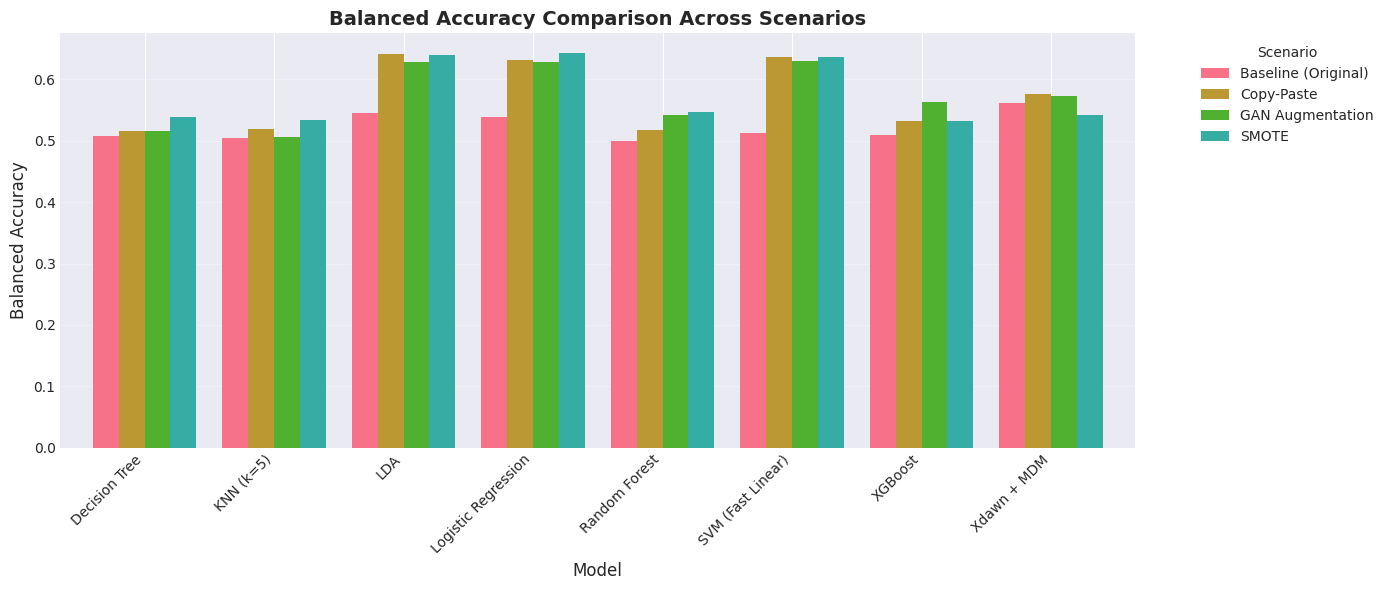

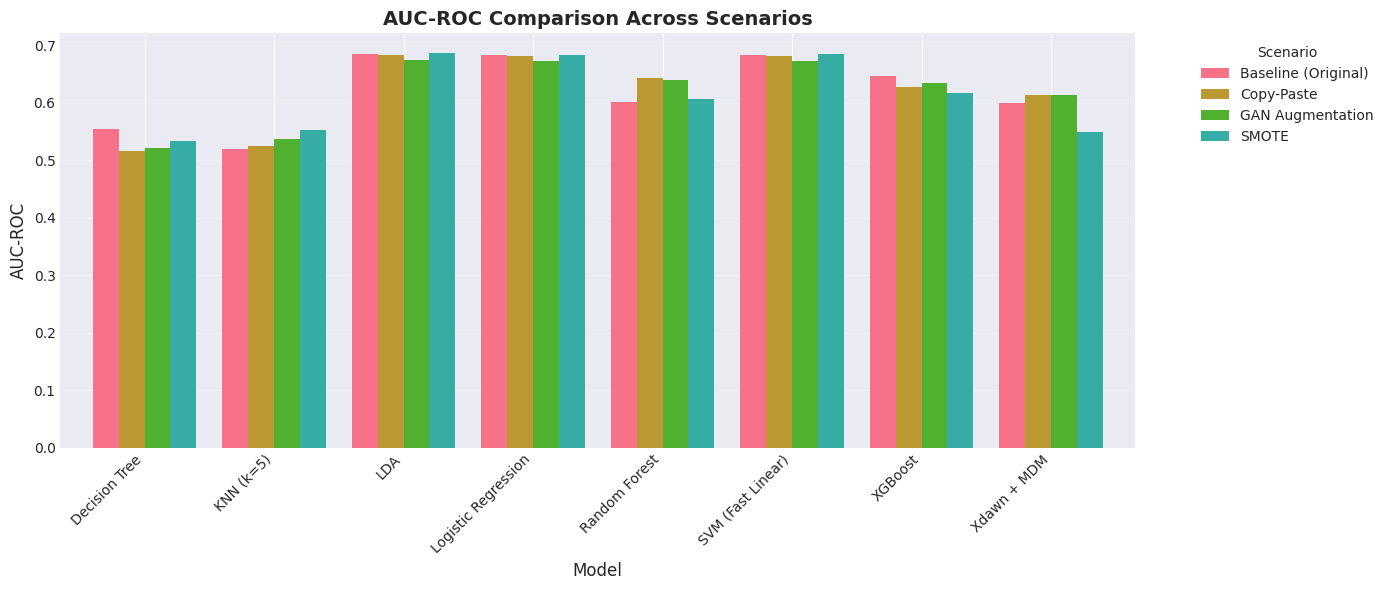

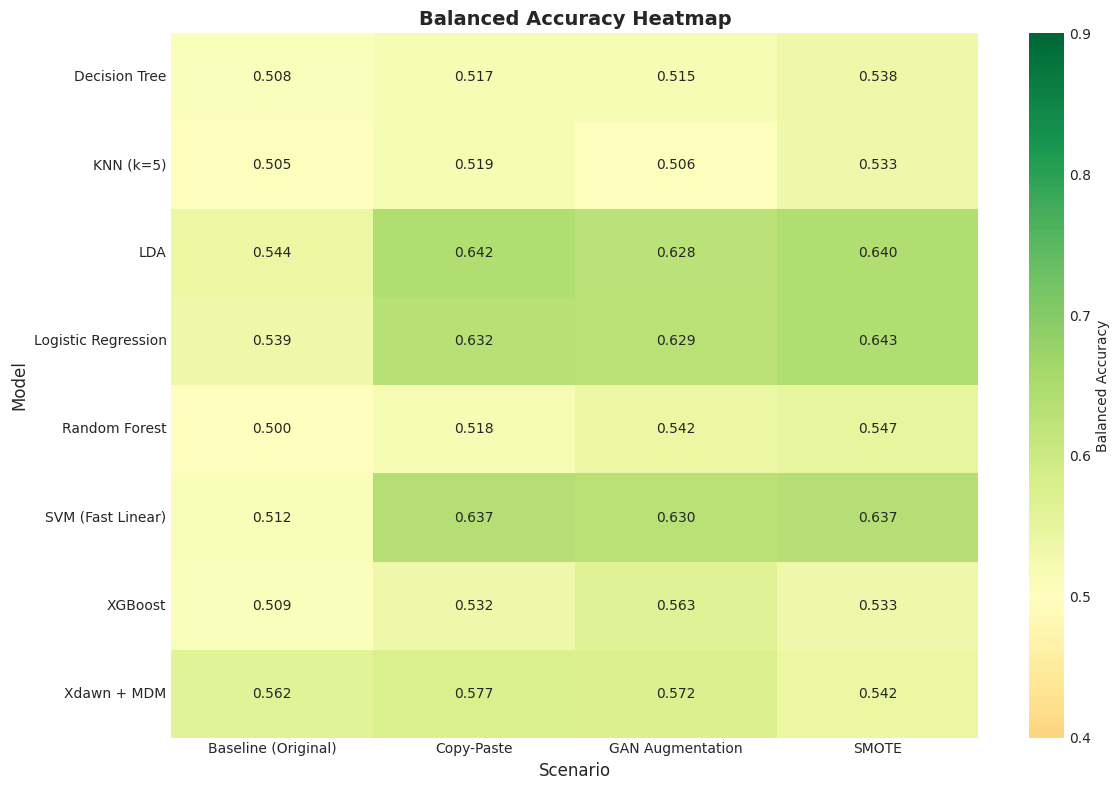


✓ Plots saved to: ../results/ml_benchmark


In [12]:
# =============================================================================
# VISUALIZATION
# =============================================================================

# Create output directory
output_dir = Path('../results/ml_benchmark')
output_dir.mkdir(parents=True, exist_ok=True)

# Plot 1: Balanced Accuracy comparison
fig, ax = plt.subplots(figsize=(14, 6))
pivot_bacc.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Balanced Accuracy Comparison Across Scenarios', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'balanced_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: AUC-ROC comparison
fig, ax = plt.subplots(figsize=(14, 6))
pivot_auc.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('AUC-ROC Comparison Across Scenarios', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'auc_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Heatmap of Balanced Accuracy
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_bacc, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, 
            vmin=0.4, vmax=0.9, ax=ax, cbar_kws={'label': 'Balanced Accuracy'})
ax.set_title('Balanced Accuracy Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / 'balanced_accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ Plots saved to: {output_dir}')

## 12. Save Results

Export results to CSV for further analysis.

In [13]:
# =============================================================================
# SAVE RESULTS
# =============================================================================

# Save complete results
results_file = output_dir / 'benchmark_results.csv'
final_report.to_csv(results_file, index=False)
print(f'\n✓ Results saved to: {results_file}')

# Save pivot tables
pivot_bacc.to_csv(output_dir / 'pivot_balanced_accuracy.csv')
pivot_auc.to_csv(output_dir / 'pivot_auc_roc.csv')
print(f'✓ Pivot tables saved')

# Summary statistics
print('\n' + '='*80)
print('SUMMARY STATISTICS')
print('='*80)

summary = final_report.groupby('Scenario')[['Accuracy', 'Balanced_Accuracy', 'AUC_ROC']].agg(['mean', 'std', 'max'])
print('\nAverage performance by scenario:')
display(summary.round(4))

print('\n✓ Benchmark complete!')


✓ Results saved to: ../results/ml_benchmark/benchmark_results.csv
✓ Pivot tables saved

SUMMARY STATISTICS

Average performance by scenario:


Accuracy                 Balanced_Accuracy          \
                        mean     std     max              mean     std   
Scenario                                                                 
Baseline (Original)   0.8266  0.0933  0.8750            0.5224  0.0228   
Copy-Paste            0.7376  0.0898  0.8768            0.5717  0.0574   
GAN Augmentation      0.7121  0.0766  0.8307            0.5732  0.0510   
SMOTE                 0.6966  0.1241  0.8271            0.5767  0.0528   

                            AUC_ROC                  
                        max    mean     std     max  
Scenario                                             
Baseline (Original)  0.5620  0.6218  0.0635  0.6858  
Copy-Paste           0.6418  0.6216  0.0673  0.6829  
GAN Augmentation     0.6300  0.6209  0.0610  0.6740  
SMOTE                0.6429  0.6143  0.0651  0.6867


✓ Benchmark complete!
